# Analyze weighted TMC runs

This notebook analyzes outputs from `tmc_weighted_*` experiments (single setting per folder).
Set the run folder and optional target island in Cell 2.

In [8]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS (edit these)
# =========================
RUN_FOLDER = "outputs/tmc_weighted_ridge_one_setting"   # Relative or absolute path
TARGET_ISLAND = None                                     # e.g. 4, or None to auto-detect

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

print("Configured run folder:", RUN_FOLDER)
print("Configured target island:", TARGET_ISLAND)

Configured run folder: outputs/tmc_weighted_ridge_one_setting
Configured target island: None


In [9]:
# Locate run folder
cwd = Path.cwd().resolve()
workspace_root = cwd
requested_path = Path(RUN_FOLDER)

if requested_path.is_absolute():
    run_dir = requested_path
else:
    run_dir = None
    for parent in [cwd, *cwd.parents]:
        candidate = (parent / requested_path).resolve()
        if candidate.exists():
            workspace_root = parent
            run_dir = candidate
            break
    if run_dir is None:
        run_dir = (cwd / requested_path).resolve()

if not run_dir.exists():
    raise FileNotFoundError(f"Could not find run folder: {run_dir}")

# Detect available targets from summary files
summary_files = sorted(run_dir.glob("weighted_ridge_summary_target_*.json"))
if len(summary_files) == 0:
    raise FileNotFoundError(f"No weighted_ridge_summary_target_*.json found in {run_dir}")

available_targets = []
for p in summary_files:
    m = re.search(r"target_(\d+)\.json$", p.name)
    if m:
        available_targets.append(int(m.group(1)))
available_targets = sorted(set(available_targets))

if TARGET_ISLAND is None:
    if len(available_targets) != 1:
        raise ValueError(f"Multiple targets found {available_targets}; set TARGET_ISLAND explicitly")
    target_island = int(available_targets[0])
else:
    target_island = int(TARGET_ISLAND)
    if target_island not in available_targets:
        raise ValueError(f"TARGET_ISLAND={target_island} not found. Available: {available_targets}")

print(f"Workspace root:   {workspace_root}")
print(f"Run folder:       {run_dir}")
print(f"Target island:    {target_island}")
print(f"Available targets:{available_targets}")

Workspace root:   C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis
Run folder:       C:\Users\Simen\OneDrive - NTNU\FYSMAT\INDMAT\MASTER\Master_thesis\outputs\tmc_weighted_ridge_one_setting
Target island:    4
Available targets:[4]


## 1) Load weighted outputs

In [10]:
summary_path = run_dir / f"weighted_ridge_summary_target_{target_island}.json"
results_repeats_path = run_dir / f"weighted_ridge_results_repeats_target_{target_island}.csv"
results_summary_path = run_dir / f"weighted_ridge_results_summary_target_{target_island}.csv"
weights_repeats_path = run_dir / f"weighted_island_weights_repeats_target_{target_island}.csv"
weights_summary_path = run_dir / f"weighted_island_weights_summary_target_{target_island}.csv"
vfull_repeats_path = run_dir / f"vfull_repeats_target_{target_island}.csv"

required = [
    summary_path,
    results_repeats_path,
    results_summary_path,
    weights_repeats_path,
    weights_summary_path,
    vfull_repeats_path,
]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))

summary_json = json.loads(summary_path.read_text(encoding="utf-8"))
results_repeats_df = pd.read_csv(results_repeats_path)
results_summary_df = pd.read_csv(results_summary_path)
weights_repeats_df = pd.read_csv(weights_repeats_path)
weights_summary_df = pd.read_csv(weights_summary_path)
vfull_repeats_df = pd.read_csv(vfull_repeats_path)

print(json.dumps(summary_json, indent=2))
display(results_summary_df)
display(results_repeats_df.head())
display(weights_summary_df.head())

{
  "target_island": 4,
  "target_island_name": "Gjer\u00f8y",
  "cal_fraction": 0.2,
  "n_permutations": 50,
  "n_repeats": 10,
  "ridge_alpha": 100000.0,
  "v_full_mean": 0.10402627106584035,
  "v_full_std": 0.12868612259396872,
  "best_method_by_mean_corr": "minmax",
  "best_corr_mean": 0.09278745729516875,
  "methods_tested": [
    "unweighted",
    "relu",
    "softmax",
    "minmax",
    "rank",
    "shifted_relu"
  ],
  "outputs": {
    "results_repeats_csv": "outputs/tmc_weighted_ridge_one_setting/weighted_ridge_results_repeats_target_4.csv",
    "results_summary_csv": "outputs/tmc_weighted_ridge_one_setting/weighted_ridge_results_summary_target_4.csv",
    "weights_repeats_csv": "outputs/tmc_weighted_ridge_one_setting/weighted_island_weights_repeats_target_4.csv",
    "weights_summary_csv": "outputs/tmc_weighted_ridge_one_setting/weighted_island_weights_summary_target_4.csv",
    "vfull_repeats_csv": "outputs/tmc_weighted_ridge_one_setting/vfull_repeats_target_4.csv"
  }
}


,method,corr_mean,corr_std,corr_p05,corr_p95,mse_mean,mse_std,gain_mean,gain_std,n_repeats
0,minmax,0.092787,0.047389,0.014656,0.145093,1.476394,0.064412,-0.011239,0.173447,10
1,rank,0.084972,0.049780,0.012674,0.147668,1.479195,0.067367,-0.019055,0.174279,10
2,softmax,0.083151,0.035347,0.026063,0.121480,1.477235,0.062008,-0.020875,0.163542,10
3,relu,0.083140,0.035342,0.026065,0.121463,1.477237,0.062007,-0.020886,0.163537,10
4,shifted_relu,0.083140,0.035342,0.026065,0.121463,1.477237,0.062007,-0.020886,0.163537,10
5,unweighted,0.083140,0.035342,0.026065,0.121463,1.477237,0.062007,-0.020886,0.163537,10


,repeat,split_seed,method,corr_eval,mse_adj,gain_over_v_full,alpha,v_full
0,0,14392265,unweighted,0.068430,1.443842,-0.097430,100000.0,0.165859
1,0,14392265,relu,0.068430,1.443842,-0.097430,100000.0,0.165859
2,0,14392265,softmax,0.068434,1.443840,-0.097425,100000.0,0.165859
3,0,14392265,minmax,0.073016,1.442565,-0.092844,100000.0,0.165859
4,0,14392265,rank,0.052378,1.448933,-0.113481,100000.0,0.165859


,method,source_island,source_island_name,n_island,phi_mean,phi_per_ind_mean,weight_mean,weight_std
0,minmax,0,Nesøy,119,0.020286,0.000170,1.553967,1.166560
1,minmax,1,Myken,92,0.017156,0.000186,1.378714,0.728477
2,minmax,2,Træna,292,0.016340,0.000056,1.119589,0.259573
3,minmax,3,Selvær,194,-0.040298,-0.000208,0.360404,0.285272
4,minmax,5,Hestmannøy,1078,0.074231,0.000069,1.098341,0.418947


In [11]:
print("n repeats in results:", results_repeats_df['repeat'].nunique())
print("methods:", sorted(results_summary_df['method'].unique()))
print("n source islands:", weights_summary_df['source_island'].nunique())
print("v_full mean/std from repeats:",
      float(vfull_repeats_df['v_full'].mean()),
      float(vfull_repeats_df['v_full'].std()))

n repeats in results: 10
methods: ['minmax', 'rank', 'relu', 'shifted_relu', 'softmax', 'unweighted']
n source islands: 15
v_full mean/std from repeats: 0.10402627106584035 0.12868612259396872


## 2) Method-level performance

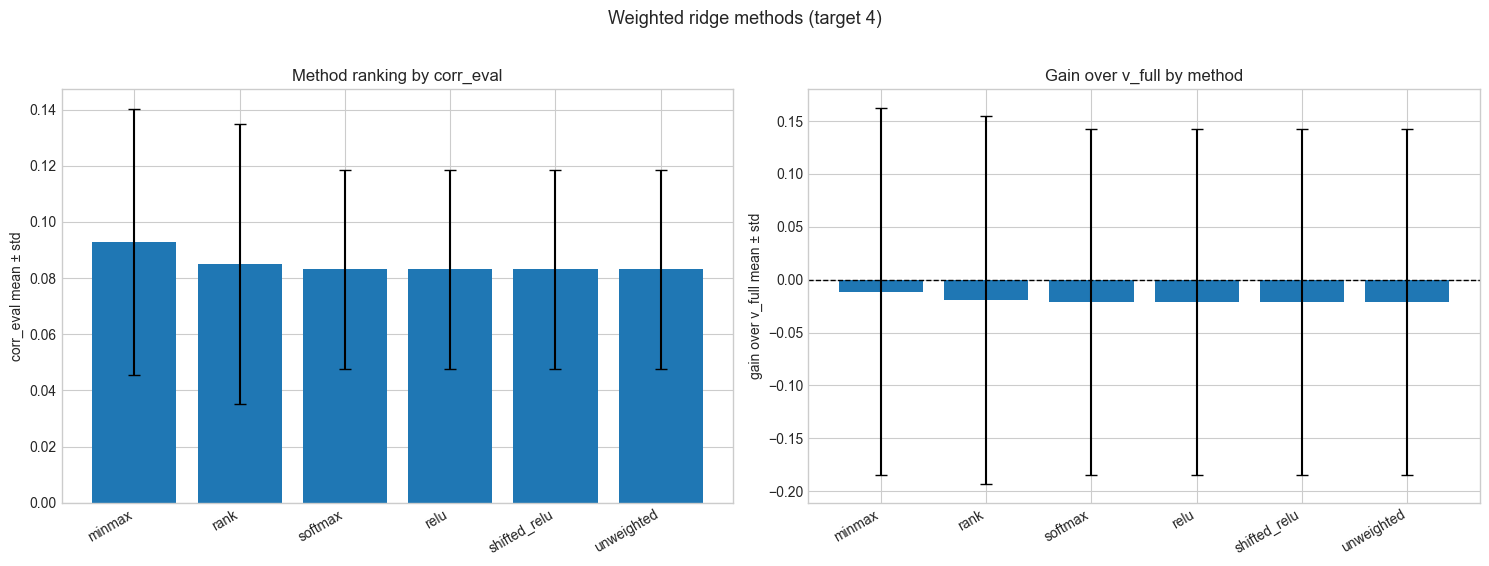

In [12]:
method_order = results_summary_df.sort_values('corr_mean', ascending=False)['method'].tolist()
plot_df = results_summary_df.set_index('method').loc[method_order].reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Corr mean ± std
ax = axes[0]
x = np.arange(len(plot_df))
ax.bar(x, plot_df['corr_mean'], yerr=plot_df['corr_std'].fillna(0), capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['method'], rotation=30, ha='right')
ax.set_ylabel('corr_eval mean ± std')
ax.set_title('Method ranking by corr_eval')

# Gain over v_full mean ± std
ax = axes[1]
ax.bar(x, plot_df['gain_mean'], yerr=plot_df['gain_std'].fillna(0), capsize=4)
ax.axhline(0, color='black', linestyle='--', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df['method'], rotation=30, ha='right')
ax.set_ylabel('gain over v_full mean ± std')
ax.set_title('Gain over v_full by method')

fig.suptitle(f"Weighted ridge methods (target {target_island})", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

C:\Users\Simen\AppData\Local\Temp\ipykernel_13760\1695514913.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(corr_data, labels=method_order, showfliers=True)


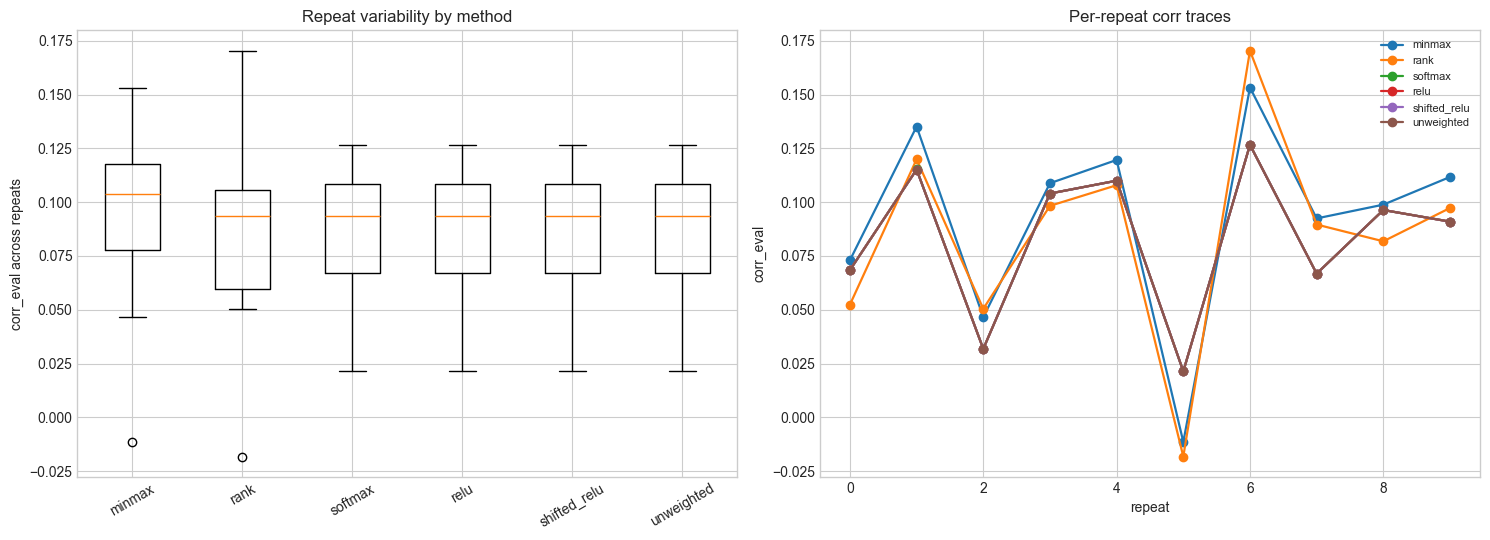

In [13]:
# Repeat-level distributions
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Boxplot corr by method
ax = axes[0]
corr_data = [
    results_repeats_df.loc[results_repeats_df['method'] == m, 'corr_eval'].to_numpy()
    for m in method_order
]
ax.boxplot(corr_data, labels=method_order, showfliers=True)
ax.tick_params(axis='x', rotation=30)
ax.set_ylabel('corr_eval across repeats')
ax.set_title('Repeat variability by method')

# Per-repeat lines (paired by split seed)
ax = axes[1]
pivot = results_repeats_df.pivot_table(index='repeat', columns='method', values='corr_eval', aggfunc='mean')
for m in method_order:
    if m in pivot.columns:
        ax.plot(pivot.index, pivot[m], marker='o', linewidth=1.6, label=m)
ax.set_xlabel('repeat')
ax.set_ylabel('corr_eval')
ax.set_title('Per-repeat corr traces')
ax.legend(loc='best', fontsize=8)

fig.tight_layout()
plt.show()

## 3) Island weight patterns

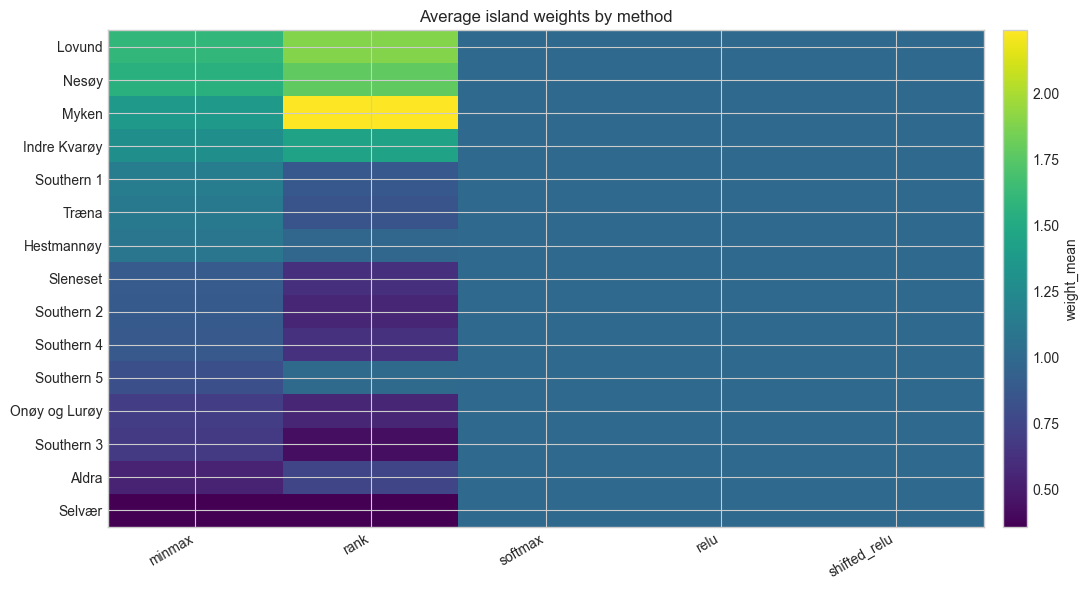

In [14]:
# Heatmap: average island weights by method
weight_heat = (
    weights_summary_df
    .pivot(index='source_island_name', columns='method', values='weight_mean')
)

# Keep method order from performance ranking where available
ordered_cols = [m for m in method_order if m in weight_heat.columns]
weight_heat = weight_heat[ordered_cols]

# Order islands by minmax weight (if present), else row mean
if 'minmax' in weight_heat.columns:
    island_order = weight_heat['minmax'].sort_values(ascending=False).index
else:
    island_order = weight_heat.mean(axis=1).sort_values(ascending=False).index
weight_heat = weight_heat.loc[island_order]

fig, ax = plt.subplots(figsize=(11, max(6, 0.35 * len(weight_heat))))
im = ax.imshow(weight_heat.values, aspect='auto', cmap='viridis')
ax.set_xticks(np.arange(len(weight_heat.columns)))
ax.set_xticklabels(weight_heat.columns, rotation=30, ha='right')
ax.set_yticks(np.arange(len(weight_heat.index)))
ax.set_yticklabels(weight_heat.index)
ax.set_title('Average island weights by method')
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('weight_mean')
fig.tight_layout()
plt.show()

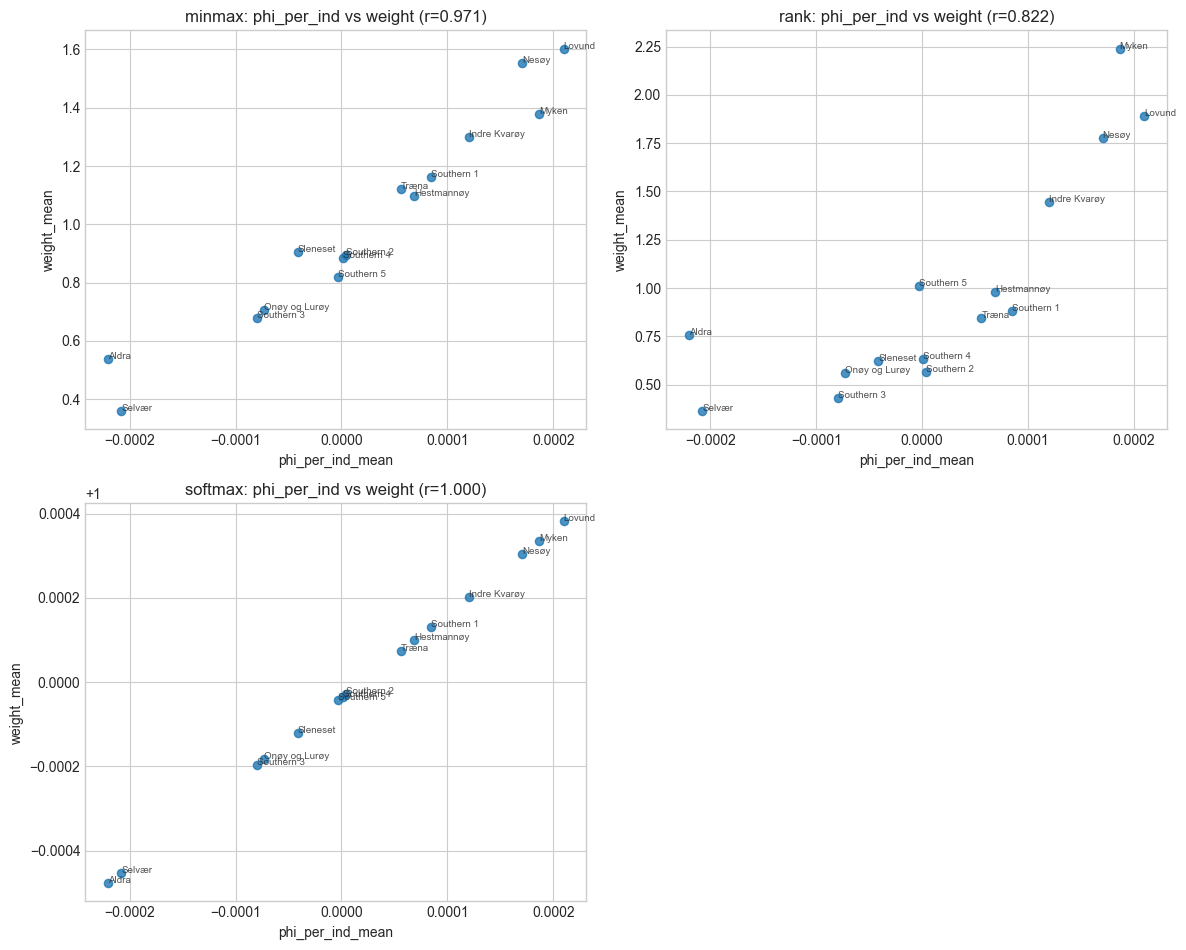

In [15]:
# Relationship between Shapley signal and learned weights
methods_for_scatter = [m for m in ['minmax', 'rank', 'softmax', 'unweighted'] if m in weights_summary_df['method'].unique()]
n_cols = 2
n_rows = int(np.ceil(len(methods_for_scatter) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4.8 * n_rows), squeeze=False)
axes = axes.ravel()

for idx, method in enumerate(methods_for_scatter):
    ax = axes[idx]
    sub = weights_summary_df[weights_summary_df['method'] == method].copy()

    x = sub['phi_per_ind_mean'].to_numpy(dtype=float)
    y = sub['weight_mean'].to_numpy(dtype=float)

    ax.scatter(x, y, s=35, alpha=0.8)
    if len(sub) >= 2:
      corr = np.corrcoef(x, y)[0, 1]
    else:
      corr = np.nan

    for _, row in sub.iterrows():
        ax.annotate(row['source_island_name'], (row['phi_per_ind_mean'], row['weight_mean']), fontsize=7, alpha=0.8)

    ax.set_title(f"{method}: phi_per_ind vs weight (r={corr:.3f})")
    ax.set_xlabel('phi_per_ind_mean')
    ax.set_ylabel('weight_mean')

for j in range(len(methods_for_scatter), len(axes)):
    axes[j].axis('off')

fig.tight_layout()
plt.show()

## 4) Cache-based rank stability (like TMC sweep notebook)

In [16]:
cache_files = sorted((run_dir / 'cache').glob(f'tmc_perm_state_target_{target_island}_seed_*.json'))
if not cache_files:
    raise FileNotFoundError(f"No cache files found for target {target_island} in {run_dir / 'cache'}")

rows = []
for file_path in cache_files:
    state = json.loads(file_path.read_text(encoding='utf-8'))
    seed = int(state['seed'])

    local_phi = np.array(state.get('local_phi_by_perm', []), dtype=float)
    if local_phi.ndim != 2 or local_phi.size == 0:
        continue

    n_perm, n_islands = local_phi.shape
    running_phi = np.cumsum(local_phi, axis=0) / np.arange(1, n_perm + 1)[:, None]

    order = np.argsort(-running_phi, axis=1)
    ranks = np.empty_like(order)
    ranks[np.arange(n_perm)[:, None], order] = np.arange(1, n_islands + 1)

    for perm_idx in range(n_perm):
        for source_island in range(n_islands):
            rows.append({
                'split_seed': seed,
                'permutation_index': perm_idx + 1,
                'source_island': source_island,
                'phi_running': float(running_phi[perm_idx, source_island]),
                'rank_running': int(ranks[perm_idx, source_island]),
            })

rank_long = pd.DataFrame(rows)
max_perm = int(rank_long['permutation_index'].max())

# Map island names from weights summary if available
name_map = (
    weights_summary_df[['source_island', 'source_island_name']]
    .drop_duplicates('source_island')
    .set_index('source_island')['source_island_name']
    .to_dict()
)
rank_long['source_island_name'] = rank_long['source_island'].map(name_map).fillna('island_' + rank_long['source_island'].astype(str))

print('Rank rows:', len(rank_long))
print('Seeds loaded:', rank_long['split_seed'].nunique())
print('Permutation max:', max_perm)
display(rank_long.head())

Rank rows: 7500
Seeds loaded: 10
Permutation max: 50


,split_seed,permutation_index,source_island,phi_running,rank_running,source_island_name
0,1198679252,1,0,0.240069,1,Nesøy
1,1198679252,1,1,-0.037545,13,Myken
2,1198679252,1,2,0.015972,4,Træna
3,1198679252,1,3,0.004972,7,Selvær
4,1198679252,1,4,0.128401,2,island_4


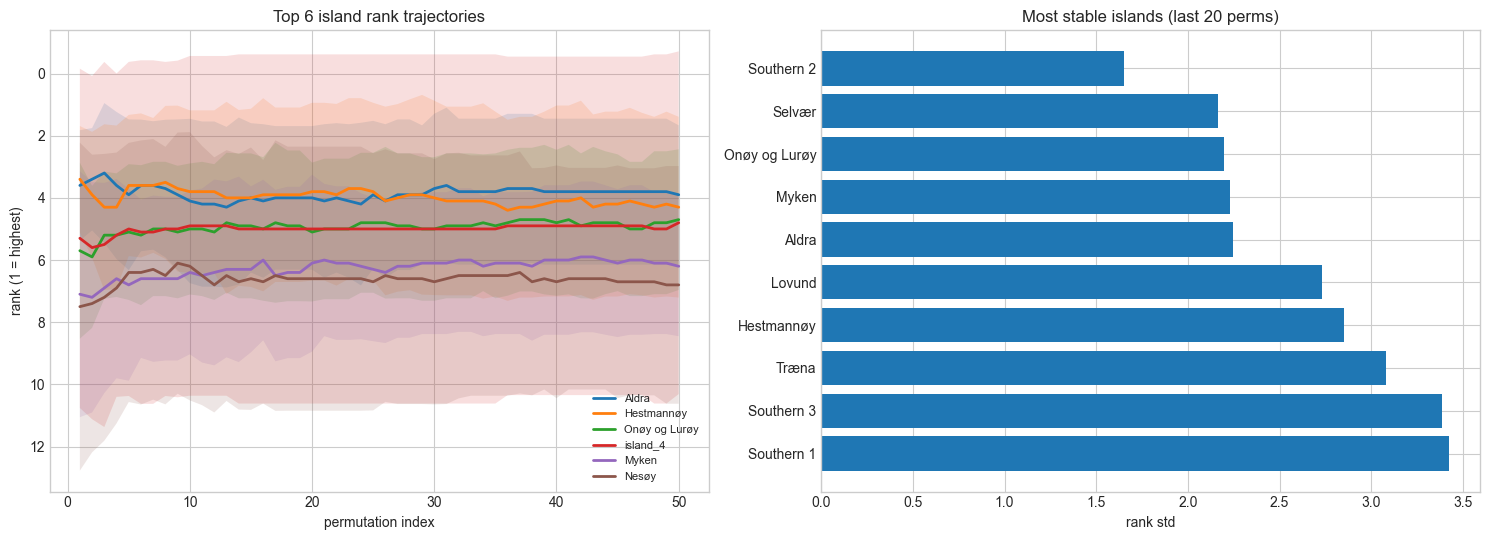

Most stable islands:


,source_island_name,rank_std_last_window
10,Southern 2,1.649577
7,Selvær,2.161791
6,Onøy og Lurøy,2.195839
4,Myken,2.230888
0,Aldra,2.244278
3,Lovund,2.729533
1,Hestmannøy,2.848591
13,Træna,3.079255
11,Southern 3,3.386995
9,Southern 1,3.422010


Most variable islands:


,source_island_name,rank_std_last_window
3,Lovund,2.729533
1,Hestmannøy,2.848591
13,Træna,3.079255
11,Southern 3,3.386995
9,Southern 1,3.422010
5,Nesøy,3.566564
2,Indre Kvarøy,3.587303
8,Sleneset,3.828890
12,Southern 4,3.859023
14,island_4,5.240459


In [17]:
# Final rank and stability summary
final_ranks = rank_long[rank_long['permutation_index'] == max_perm].copy()
final_rank_mean = (
    final_ranks.groupby('source_island_name', as_index=False)['rank_running']
    .mean()
    .rename(columns={'rank_running': 'final_rank_mean'})
    .sort_values('final_rank_mean')
)

top_k = min(6, len(final_rank_mean))
top_islands = final_rank_mean.head(top_k)['source_island_name'].tolist()

traj = rank_long[rank_long['source_island_name'].isin(top_islands)].copy()
traj_stats = (
    traj.groupby(['source_island_name', 'permutation_index'], as_index=False)['rank_running']
    .agg(rank_mean='mean', rank_std='std')
)

tail_window = min(20, max_perm)
tail_start = max_perm - tail_window + 1
tail_df = rank_long[rank_long['permutation_index'] >= tail_start].copy()
stability = (
    tail_df.groupby('source_island_name', as_index=False)['rank_running']
    .std()
    .rename(columns={'rank_running': 'rank_std_last_window'})
    .sort_values('rank_std_last_window')
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Top-island trajectories
ax = axes[0]
for island in top_islands:
    g = traj_stats[traj_stats['source_island_name'] == island]
    ax.plot(g['permutation_index'], g['rank_mean'], linewidth=2, label=island)
    std_vals = g['rank_std'].fillna(0)
    ax.fill_between(g['permutation_index'], g['rank_mean'] - std_vals, g['rank_mean'] + std_vals, alpha=0.15)
ax.set_title(f"Top {top_k} island rank trajectories")
ax.set_xlabel('permutation index')
ax.set_ylabel('rank (1 = highest)')
ax.invert_yaxis()
ax.legend(loc='best', fontsize=8)

# Stability barplot
ax = axes[1]
show_n = min(10, len(stability))
stab_show = stability.head(show_n).iloc[::-1]
ax.barh(stab_show['source_island_name'], stab_show['rank_std_last_window'])
ax.set_title(f"Most stable islands (last {tail_window} perms)")
ax.set_xlabel('rank std')

fig.tight_layout()
plt.show()

print('Most stable islands:')
display(stability.head(10))
print('Most variable islands:')
display(stability.tail(10))